In [1]:
import pandas as pd
import wandb
from scipy import stats

wandb.login(key="cf344975eb80edf6f0d52af80528cc6094234caf")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/rahul/.netrc
wandb: Currently logged in as: rahul-e-dev to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [8]:
api = wandb.Api()
runs = api.runs("rahul-e-dev/evaluate_chameleon")

In [9]:
# import torch
# chemeleon_mp = torch.load("./chemeleon_mp.pt", weights_only=True)
# from chemprop.nn import BondMessagePassing

# chemeleon_mpchemeleon_mp = torch.load("./chemeleon_mp.pt", weights_only=True)
# mp = BondMessagePassing(**chemeleon_mp["hyper_parameters"])  # type: ignore
# mp.load_state_dict(chemeleon_mp["state_dict"])

In [10]:
cols = [
    'outer', 
    'inner', 
    'average_precision', 
    'roc_auc',
    'accuracy', 
    'balanced_accuracy', 
    'precision', 
    'recall',
    'f1', 
    'mcc',
    'dataset',
    'split_type',
    'model'
]

In [11]:
df = pd.concat([
    pd.DataFrame.from_records(list(run.scan_history()))
    for run in runs
]).loc[:, cols]

In [12]:
metrics = [
    # 'outer', 
    # 'inner', 
    'average_precision', 
    'roc_auc',
    # 'accuracy', 
    # 'balanced_accuracy', 
    'precision', 
    'recall',
    'f1', 
    'mcc',
    # 'dataset',
    # 'split_type',
    # 'model'
]

In [13]:
from scipy.stats import ttest_rel
import pingouin as pg


entries = []
for ds in df["dataset"].unique()[:6]:
    # print("=============================================================")
    # print(ds)
    # print("=============================================================")
    for m in metrics:
        sub_df = df[
            (df["dataset"] == ds) & (df["split_type"] == "scaffold")
        ]

        try:
            res = pg.ttest(
                sub_df.query("model == 'deltaprop'")[m],
                sub_df.query("model == 'baseline'")[m],
                paired=True,
                confidence=0.95
            )

            deltaprop_mean = sub_df.query("model == 'deltaprop'")[m].mean()
            deltaprop_sd = sub_df.query("model == 'deltaprop'")[m].std()
            baseline_mean = sub_df.query("model == 'baseline'")[m].mean()
            baseline_sd = sub_df.query("model == 'baseline'")[m].std()
            mean_diff = (
                sub_df.query("model == 'deltaprop'")[m] - 
                sub_df.query("model == 'baseline'")[m]
            ).mean()

            pval = res.loc[:, "p-val"].iloc[0]
            cohens_d = res.loc[:, "cohen-d"].iloc[0]
            ci_l = res.loc[:, "CI95%"].iloc[0][0]
            ci_r = res.loc[:, "CI95%"].iloc[0][1]

            entries.append(dict(
                dataset=ds,
                metric = m,
                deltaprop = f"{deltaprop_mean:.3f} (+/-) {deltaprop_sd:.3f}",
                baseline = f"{baseline_mean:.3f} (+/-) {baseline_sd:.3f}",
                mean_diff = f"{mean_diff:.3f}",
                ci_95 = f"[{ci_l:6.3f}, {ci_r:6.3f}]",
                cohens_d = f"{cohens_d:.3f}",
                p_value_uncorrected = f"{pval:.3f}"
            ))

        
            # pval = ttest_rel(
            #     sub_df.query("model == 'deltaprop'")[m],
            #     sub_df.query("model == 'baseline'")[m]
            # ).pvalue

            # # print(pval)
            # if not pd.isna(pval):
            #     pvals.append(pval)

        
            # cohens_d = pg.compute_effsize(
            #     sub_df.query("model == 'deltaprop'")[m],
            #     sub_df.query("model == 'baseline'")[m], 
            #     paired=True, 
            #     eftype="cohen"
            # )
            
        except:
            continue

        # print(f"{m:20}\t{pval:8.3f}\t{cohens_d:8.3f}\t[{ci_l:6.3f}, {ci_r:6.3f}]")

    # print()

asd = pd.DataFrame.from_records(entries)
asd.set_index(['dataset', 'metric'])
# asd.to_csv("random_results.csv")

/home/rahul/delta/.venv/lib/python3.12/site-packages/pingouin/parametric.py:228: UserWarning: x and y have unequal sizes. Switching to paired == False. Check your data.
  warnings.warn("x and y have unequal sizes. Switching to paired == False. Check your data.")
/home/rahul/delta/.venv/lib/python3.12/site-packages/pingouin/parametric.py:257: RuntimeWarning: Degrees of freedom <= 0 for slice
  vx, vy = x.var(ddof=1), y.var(ddof=1)
/home/rahul/delta/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/rahul/delta/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/rahul/delta/.venv/lib/python3.12/site-packages/pingouin/parametric.py:261: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for s

deltaprop           baseline  \
dataset           metric                                                    
SINGLE_TARGET_TBA average_precision  0.809 (+/-) 0.059  0.824 (+/-) 0.062   
                  roc_auc            0.824 (+/-) 0.053  0.832 (+/-) 0.063   
                  precision          0.661 (+/-) 0.065  0.633 (+/-) 0.070   
                  recall             0.868 (+/-) 0.099  0.882 (+/-) 0.124   
                  f1                 0.744 (+/-) 0.041  0.732 (+/-) 0.072   
                  mcc                0.475 (+/-) 0.095  0.441 (+/-) 0.154   
DUAL_TARGET_TBA   average_precision  0.370 (+/-) 0.138  0.283 (+/-) 0.119   
                  roc_auc            0.686 (+/-) 0.104  0.623 (+/-) 0.134   
                  precision          0.215 (+/-) 0.098  0.187 (+/-) 0.083   
                  recall             0.645 (+/-) 0.212  0.564 (+/-) 0.281   
                  f1                 0.305 (+/-) 0.089  0.258 (+/-) 0.091   
                  mcc                0.162 (+/-) 0.139  0.109 (+/-) 0.124   

                                    mean_diff             ci_95 cohens_d  \
dataset           metric                                                   
SINGLE_TARGET_TBA average_precision    -0.015  [-0.050,  0.020]    0.253   
                  roc_auc              -0.008  [-0.040,  0.020]    0.134   
                  precision             0.027  [-0.010,  0.060]    0.403   
                  recall               -0.013  [-0.080,  0.060]    0.119   
                  f1                    0.013  [-0.020,  0.040]    0.215   
                  mcc                   0.034  [-0.030,  0.100]    0.269   
DUAL_TARGET_TBA   average_precision     0.088  [ 0.010,  0.170]    0.681   
                  roc_auc               0.062  [-0.010,  0.140]    0.521   
                  precision             0.029  [-0.030,  0.090]    0.314   
                  recall                0.081  [-0.040,  0.200]    0.325   
                  f1                    0.047  [-0.010,  0.100]    0.520   
                  mcc                   0.053  [-0.030,  0.140]    0.402   

                                    p_value_uncorrected  
dataset           metric                                 
SINGLE_TARGET_TBA average_precision               0.386  
                  roc_auc                         0.627  
                  precision                       0.146  
                  recall                          0.697  
                  f1                              0.417  
                  mcc                             0.303  
DUAL_TARGET_TBA   average_precision               0.032  
                  roc_auc                         0.104  
                  precision                       0.327  
                  recall                          0.177  
                  f1                              0.104  
                  mcc                             0.199

In [9]:
from stats_utils import (
    make_boxplots_nonparametric,
    make_boxplots_parametric,
    make_ci_plot_grid,
    make_mcs_plot_grid,
    make_normality_diagnostic,
    rm_tukey_hsd,
)


make_normality_diagnostic(df.query("dataset == 'DB_MALARIA'").copy(), metrics)

KeyError: 'method'

ValueError: The data set contains more than one observation per subject and cell. Either aggregate the data manually, or pass the `aggregate_func` parameter.

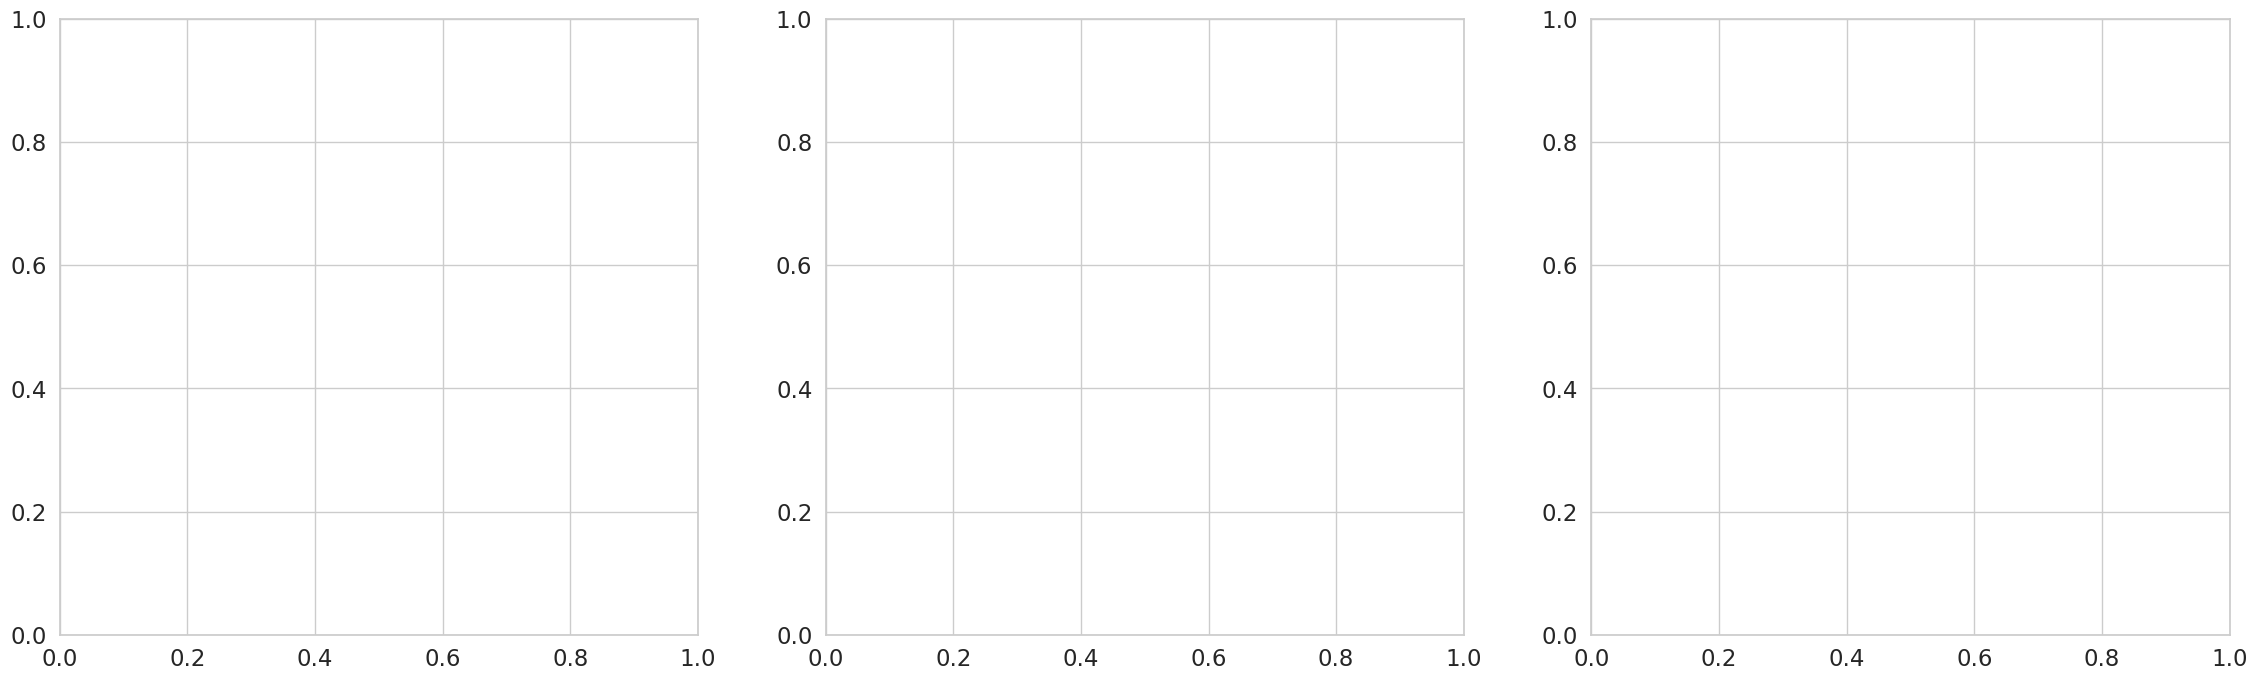

In [58]:
make_boxplots_parametric(df.query("dataset == 'DB_MALARIA'").copy(), metrics)

In [59]:
df.query("dataset == 'DB_MALARIA'")

,outer,inner,average_precision,roc_auc,accuracy,balanced_accuracy,precision,recall,f1,mcc,dataset,split_type,model,method,split,cv_cycle
0,0,0,0.051204,0.422575,0.943662,0.500000,0.000000,0.000000,0.000000,0.000000,DB_MALARIA,scaffold,baseline,baseline,scaffold,0
1,0,1,0.055410,0.480423,0.408451,0.485714,0.047059,0.571429,0.086957,-0.012618,DB_MALARIA,scaffold,baseline,baseline,scaffold,1
2,0,2,0.076246,0.583333,0.841379,0.448529,0.000000,0.000000,0.000000,-0.084097,DB_MALARIA,scaffold,baseline,baseline,scaffold,2
3,0,3,0.045213,0.378465,0.943262,0.496269,0.000000,0.000000,0.000000,-0.019317,DB_MALARIA,scaffold,baseline,baseline,scaffold,3
4,0,4,0.043333,0.388060,0.347518,0.521322,0.052632,0.714286,0.098039,0.019757,DB_MALARIA,scaffold,baseline,baseline,scaffold,4
5,1,0,0.035976,0.259259,0.943662,0.496296,0.000000,0.000000,0.000000,-0.019177,DB_MALARIA,scaffold,baseline,baseline,scaffold,1
6,1,1,0.045694,0.408316,0.531915,0.482942,0.046154,0.428571,0.083333,-0.014866,DB_MALARIA,scaffold,baseline,baseline,scaffold,2
7,1,2,0.064576,0.448529,0.937931,0.500000,0.000000,0.000000,0.000000,0.000000,DB_MALARIA,scaffold,baseline,baseline,scaffold,3
8,1,3,0.038762,0.314499,0.304965,0.363539,0.030928,0.428571,0.057692,-0.127946,DB_MALARIA,scaffold,baseline,baseline,scaffold,4
9,1,4,0.078379,0.557836,0.288732,0.505597,0.057143,0.750000,0.106195,0.005880,DB_MALARIA,scaffold,baseline,baseline,scaffold,5


In [ ]:
from statsmodels.stats.multitest import multipletests

In [ ]:
adjusted = multipletests(pvals, method='holm')

In [ ]:
def load_run(run_name):
    api = wandb.Api()
    runs = api.runs("rahul-e-dev/evaluate_all")
    run = next(run for run in runs if run.name == run_name)
    
    cols = [
        # 'outer', 
        # 'inner', 
        'average_precision', 
        'roc_auc',
        'accuracy', 
        'balanced_accuracy', 
        'precision', 
        'recall',
        'f1', 
        'mcc',
    ]

    df = pd.DataFrame.from_records(list(run.scan_history()))
    df = df.loc[:, cols]
    return df

In [ ]:
baseline_df = load_run("skilled-thunder-81")
deltaprop_df = load_run("solar-disco-82")

In [ ]:
baseline_df["method"] = "baseline"
deltaprop_df["method"] = "deltaprop"

baseline_df = baseline_df.reset_index(names=["cv_cycle"])
deltaprop_df = deltaprop_df.reset_index(names=["cv_cycle"])

In [ ]:
fin_df = pd.concat([baseline_df, deltaprop_df])
fin_df["split"] = "scaffold"

In [ ]:
metric_ls = [
    'average_precision', 
    'roc_auc',
    # 'accuracy', 
    # 'balanced_accuracy', 
    'precision', 
    'recall',
    'f1', 
    'mcc',
]

In [ ]:
for metric in metric_ls:
    groups = fin_df.groupby('method')[metric].apply(list)
    stat, pvalue = stats.levene(*groups)
    print(f'Levene test for {metric}: p-value = {pvalue}')

In [ ]:
variances_by_method = fin_df.groupby('method')[metric_ls].var()
max_fold_diff = variances_by_method.max() / variances_by_method.min()
print(max_fold_diff)

In [ ]:
make_boxplots_parametric(fin_df.copy(), metric_ls)

In [ ]:
effect_dict = {m: 0.1 for m in metric_ls}
direction_dict = {m: "maximize" for m in metric_ls} 

make_mcs_plot_grid(fin_df, metric_ls, group_col="method", effect_dict=effect_dict, direction_dict=direction_dict,
                   figsize=(22, 14), cell_text_size=20, axis_text_size=18, title_text_size=26, show_diff=True, sort_axes=True)

In [ ]:
for i, metric in enumerate(metric_ls):
    df_tukey, _, _, _ = rm_tukey_hsd(fin_df, metric, group_col="method")
    print(df_tukey)

In [ ]:
df_tukey

In [ ]:
make_ci_plot_grid(fin_df, metric_ls, "method")

In [ ]:
import pandas as pd
import pingouin as pg

df = pd.DataFrame({
    'white': {0: 10, 1: 8, 2: 7, 3: 9, 4: 7, 5: 4, 6: 5, 7: 6, 8: 5, 9: 10, 10: 4, 11: 7},
    'red': {0: 7, 1: 5, 2: 8, 3: 6, 4: 5, 5: 7, 6: 9, 7: 6, 8: 4, 9: 6, 10: 7, 11: 3},
    'rose': {0: 8, 1: 5, 2: 6, 3: 4, 4: 7, 5: 5, 6: 3, 7: 7, 8: 6, 9: 4, 10: 4, 11: 3}})
pg.friedman(df)